In [1]:
import pandas as pd
from  sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
encode = LabelEncoder()
df["Gender"] = encode.fit_transform(df["Gender"])

In [4]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [5]:
model = KMeans(n_clusters=2,random_state=24)
res = model.fit_predict(df)  # fit_predict return a cluster label.

In [6]:
res

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0], dtype=int32)

In [7]:
df["Result"] =res

In [8]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Result
0,1,1,19,15,39,1
1,2,1,21,15,81,1
2,3,0,20,16,6,1
3,4,0,23,16,77,1
4,5,0,31,17,40,1


In [9]:
c1 = df[df["Result"]==0]
c2 = df[df["Result"]==1]

In [10]:
model.cluster_centers_  # it's return the best centers values.

array([[150.        ,   0.47524752,  37.77227723,  81.35643564,
         50.45544554],
       [ 50.        ,   0.4040404 ,  39.94949495,  39.34343434,
         49.93939394]])

In [11]:
model.n_iter_

9

In [12]:
res =[]
for i in range(1,6):
    model = KMeans(n_clusters=i)
    model.fit_predict(df)
    res.append(model.inertia_)

In [13]:
res

[975562.055,
 387065.71377137717,
 272141.9514095961,
 195434.12419871794,
 165385.84484986792]

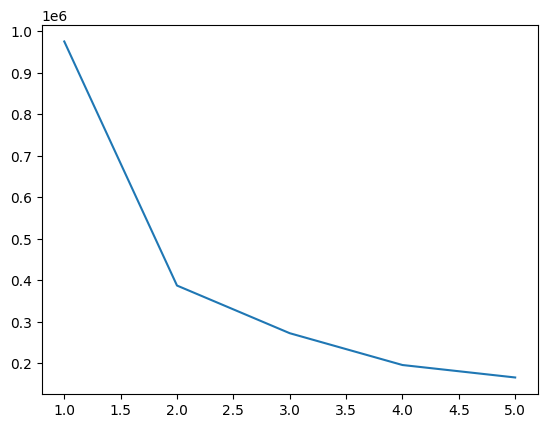

In [14]:
import matplotlib.pyplot as plt
plt.plot(range(1,6),res)

*OBSERVATION*

the best clustrs is 2.

why mean its model comes under elbow  algorithm.


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

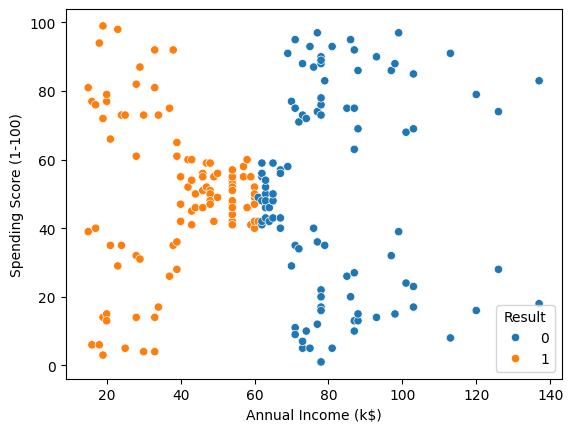

In [15]:
sns.scatterplot(df,x="Annual Income (k$)",y="Spending Score (1-100)",hue ="Result")

In [16]:
model = KMeans(n_clusters=2,random_state=42)
model.fit_transform(df) # fit_transform return a cluster distance

array([[ 59.60293317, 164.58759838],
       [ 64.96770406, 165.89976192],
       [ 71.29328064, 167.85061816],
       [ 60.66828624, 162.82359499],
       [ 51.99305068, 159.13251317],
       [ 58.62364595, 160.56234197],
       [ 65.26770471, 162.62913625],
       [ 66.69578565, 162.15305176],
       [ 69.83512   , 163.43351304],
       [ 50.98707051, 154.96492199],
       [ 62.91725001, 159.35450957],
       [ 65.4939626 , 159.05285353],
       [ 57.35776915, 155.56698699],
       [ 51.54604243, 152.17137394],
       [ 54.52285727, 152.95226175],
       [ 51.93483237, 150.94848087],
       [ 40.90632987, 146.90024337],
       [ 44.90837524, 147.05666153],
       [ 42.56918962, 145.70694282],
       [ 59.17423806, 150.24935814],
       [ 36.39311936, 142.05137237],
       [ 42.13140273, 142.64089202],
       [ 54.69053937, 146.42461081],
       [ 38.65196358, 140.02658276],
       [ 47.35919636, 141.65265116],
       [ 43.04419323, 138.9107496 ],
       [ 31.70435629, 135.53589389],
 

In [17]:
from sklearn.decomposition import PCA

In [18]:
df = df.drop(columns = ["Result","CustomerID"])

In [19]:
pca = PCA(n_components=0.8)   # components it's reduce the dimention which we give the value. now we give 2 so is reduce 2-D
pca_values = pca.fit_transform(df)
pca.explained_variance_

array([700.26443231, 684.33184134])

In [20]:
pca.explained_variance_ratio_

array([0.45118077, 0.44091539])